In [1]:
from toolbox.pattern_trainer import train_random_cells, resume_run, remove_last_iteration
remove_last_iteration("test_5_cells/")

Removed iteration 851


In [2]:






import os
import numpy as np
stresses = np.loadtxt("init_homogeneous/stresses.txt")

#  increase:
test_dir = "test_increase/"
# os.system("rm -rf {}".format(test_dir))
os.system("cp -r init_homogeneous/000  {}".format(test_dir))
os.system("echo '0\n{}' > {}stress_limits".format(np.mean(stresses),test_dir))
os.system("echo '{}' > {}target".format(np.mean(stresses) + 2*np.std(stresses),test_dir))
os.system("echo '1e-12' > {}tolerance".format(test_dir))
os.system("echo '1' > {}n_cells".format(test_dir))

#   decrease:
test_dir = "test_decrease/"
# os.system("rm -rf {}".format(test_dir))
os.system("cp -r init_homogeneous/000  {}".format(test_dir))
os.system("echo '{}\n100' > {}stress_limits".format(np.mean(stresses),test_dir))
os.system("echo '{}' > {}target".format(np.mean(stresses) - 2*np.std(stresses),test_dir))
os.system("echo '1e-12' > {}tolerance".format(test_dir))
os.system("echo '1' > {}n_cells".format(test_dir))




0

In [6]:
import os
import numpy as np
test_dir = "test_5_cells/"
stresses = np.loadtxt("init_homogeneous/stresses.txt")
os.system("cp -r init_homogeneous/010  {}".format(test_dir))
os.system("echo '1e-13' > {}tolerance".format(test_dir))
os.system("echo '10' > {}learning_rate".format(test_dir))
os.system("echo '5' > {}n_cells".format(test_dir))
os.system("echo '{}' > {}target".format(np.mean(stresses),test_dir))



0

In [ ]:
from toolbox.periodic import PeriodicTissue
from toolbox import stress
from toolbox.training import Training
import os
import numpy as np
stresses =[]
for i in range(100):
    dir = "init_homogeneous/{:03d}/".format(i)
    # os.system("scp shabeebameen@macbookpro.lan:/Users/shabeebameen/Projects/tvm-fire/{}sample.topo {}".format(dir,dir))
    file = "minimized.txt"
#     if not os.path.isfile (dir+file):
#         continue
    tissue = PeriodicTissue.from_config(dir,file)
    stresses.extend([stress.calculate_max_shear_stress(tissue,cellID) for cellID in tissue.cells_])
print(np.mean(stresses), np.std(stresses))
np.savetxt("init_homogeneous/stresses.txt", stresses)

In [ ]:
os.system("echo {} > test/target".format(np.mean(stresses+2*np.std(stresses))))

In [1]:
## vtk matters
from toolbox import manuscriptPlots
from toolbox.periodic import PeriodicTissue
from toolbox.training import Training
from toolbox.stress import calculate_max_shear_stress
import numpy as np
import pandas as pd
import os

dir = "tests/6_5.0/"
os.makedirs(dir + "vtk_files/", exist_ok=True)
df_target= pd.read_csv("{}0000.stresses.csv".format(dir))
target_cells = df_target["CellID"].to_numpy()
target_stress = df_target["Target"].to_numpy()[0]




input_file = "init_config.txt"
sample = PeriodicTissue.from_config(dir,input_file)
df = pd.read_csv("{}initial_stress.csv".format(dir))
for i, row in df.iterrows():
    cellID = int(row["cellID"])
    error = abs((target_stress-row["Stress"])/row["Stress"])
    for polygonID in sample.cells_[cellID].polygons_:
        sample.polygons_[polygonID].vtk_scalar_ = error
    
sample.write_cell_collection_vtk(cells_array=target_cells,filename="{}0000.target.vtk".format("vtk_files/"),use_scalar=True)
sample.write_periodic_vtk(filename = "{}0000.bulk.vtk".format("vtk_files/"))

for iter in [20*i-1 for i in range(1,31)]:   
    input_file = "{:04d}.bulk.txt".format(iter)
    sample = PeriodicTissue.from_config(dir,input_file)
    df = pd.read_csv("{}{:04d}.stresses.csv".format(dir,iter))
    for i, row in df.iterrows():
        cellID = int(row["CellID"])
        error = abs((target_stress-row["Current"])/row["Current"])
        for polygonID in sample.cells_[cellID].polygons_:
            sample.polygons_[polygonID].vtk_scalar_ = error
        
    sample.write_cell_collection_vtk(cells_array=target_cells,filename="{}{:04d}.target.vtk".format("vtk_files/",iter+1),use_scalar=True)
    sample.write_periodic_vtk(filename = "{}{:04d}.bulk.vtk".format("vtk_files/",iter+1))

# for iter in range(1215,1216):
#     input_file = "{:04d}.bulk.txt".format(iter)
#     sample = PeriodicTissue.from_config(dir,input_file)
#     df = pd.read_csv("{}{:04d}.stresses.csv".format(dir,iter))
#     for i, row in df.iterrows():
#         cellID = int(row["CellID"])
#         error = abs((target_stress-row["Current"])/row["Current"])
#         for polygonID in sample.cells_[cellID].polygons_:
#             sample.polygons_[polygonID].vtk_scalar_ = error
        
#     sample.write_cell_collection_vtk(cells_array=target_cells,filename="{}{:04d}.target.vtk".format("vtk_files/",iter+1),use_scalar=True)
#     sample.write_periodic_vtk(filename = "{}{:04d}.bulk.vtk".format("vtk_files/",iter+1))
# plotter = manuscriptPlots.plot()
# plotter.set_ylim(0,7)
# plotter.set_xlim(0,0.75)
# plotter.set_xlabel(r"$\sigma_{shear}$")
# plotter.set_xticks([0.25*i for i in range(10)])
# plotter.set_yticks([5*i for i in range(1,10)])
# # plotter.set_yScaled()
# plotter.initialize_figure()
# # plotter.ax.set_xscale("log")
# # plotter.ax.set_yscale("log")
# # errors = np.loadtxt(dir+ "errors.txt")
# # epochs = [i+1 for i in range(len(errors))]
# # plotter.plot_xy(epochs,errors,label = "Error", color= "red",alpha = 0.8)
# # # plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)
# plotter.histogram_from_array(stresses,bins = 40,alpha = 0.4)
# for i,stress in enumerate(df["Stress"].to_numpy()):
#     plotter.ax.vlines(stress, ymin = 0, ymax = 5,linestyles= "--", color = colors[i],alpha = 0.5)
# plotter.ax.vlines(target_stress, ymin = 0, ymax = 6.5,linestyles= "--", color = "red",alpha = 1,label = r"$\sigma_{target}$")
# plotter.ax.legend()
# plotter.save_fig(dir+"animation_assets/"+"0000.stress.jpg")

# # for iter in [20*i-1 for i in range(1,1216)]:
# for iter in range(1215,1216):

#     input_file = "{:04d}.bulk.txt".format(iter)
#     sample = PeriodicTissue.from_config(dir,input_file)
#     training_instance = Training.periodic_tissue(sample)
#     training_instance.load_cell_parameters("{:04d}.cellParameters.input".format(iter))
#     stresses = [calculate_max_shear_stress(training_instance._config,cellID) for cellID in training_instance._config.cells_]
#     df = pd.read_csv("{}{:04d}.stresses.csv".format(dir,iter))

#     plotter = manuscriptPlots.plot()
#     plotter.set_ylim(0,7)
#     plotter.set_xlim(0,0.75)
#     # plotter.set_title(" p = {:.2f}".format(p))
#     plotter.set_xlabel(r"$\sigma_{shear}$")
#     # plotter.set_ylabel(r"$<\frac{|\sigma_{target}-\sigma|}{\sigma}>$")
#     # # plotter.set_ylabel(r"$<\sum_{cells}{|s_{0,cell}^{(A)}-s_{0,cell}^{(B)}|}>$")

#     plotter.set_xticks([0.25*i for i in range(10)])
#     plotter.set_yticks([5*i for i in range(1,10)])
#     # plotter.set_yScaled()
#     plotter.initialize_figure()
#     # plotter.ax.set_xscale("log")
#     # plotter.ax.set_yscale("log")
#     # errors = np.loadtxt(dir+ "errors.txt")
#     # epochs = [i+1 for i in range(len(errors))]
#     # plotter.plot_xy(epochs,errors,label = "Error", color= "red",alpha = 0.8)
#     # # plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)
#     plotter.histogram_from_array(stresses,bins = 40,alpha = 0.4)
#     for i,stress in enumerate(df["Current"].to_numpy()):
#         plotter.ax.vlines(stress, ymin = 0, ymax = 5,linestyles= "--", color = colors[i],alpha = 0.5)
#     plotter.ax.vlines(target_stress, ymin = 0, ymax = 6.5,linestyles= "--", color = "red",alpha = 1,label = r"$\sigma_{target}$")
#     plotter.ax.legend()
#     plotter.save_fig(dir+"animation_assets/"+"{:04d}.stress.jpg".format(iter+1))


In [ ]:
# s0 histogram

from toolbox import manuscriptPlots
from toolbox.periodic import PeriodicTissue
from toolbox.training import Training
from toolbox.stress import calculate_max_shear_stress
# import numpy as np
import pandas as pd
import os

dir = "test_decrease_fail/"
os.makedirs(dir + "graphs/", exist_ok=True)

colors = ["blue","red"]
labels = [0.25,1]

plotter = manuscriptPlots.plot()
plotter.set_ylim(0,20)
plotter.set_xlim(4.98,5.5)
plotter.set_xlabel(r"$s_0^{(hidden)}$")
plotter.set_xticks([0.2*i for i in range(200)])
plotter.set_yticks([5*i for i in range(1,10)])
plotter.initialize_figure()
plotter.ax.vlines(5, ymin = 0, ymax = 9,linestyles= "--", color = "black",alpha = 0.3, label= "Initial")

for i,iter in enumerate([115,229]):
    input_file = dir + "{:04d}.cellParameters.input".format(iter)
    s0_vals =[]
    with open(input_file,"r") as f:
        lines = f.readlines()
        for line in lines:
            s0_vals.append(float(line.split()[2]))
    plotter.histogram_from_array(s0_vals,bins = 20,alpha = 0.4, color = colors[i],label= r"$\frac{I}{I_f} = $"+"{:.2f}".format(labels[i]))
plotter.ax.legend()
plotter.save_fig(dir+"graphs/"+"s0.jpg".format(iter))

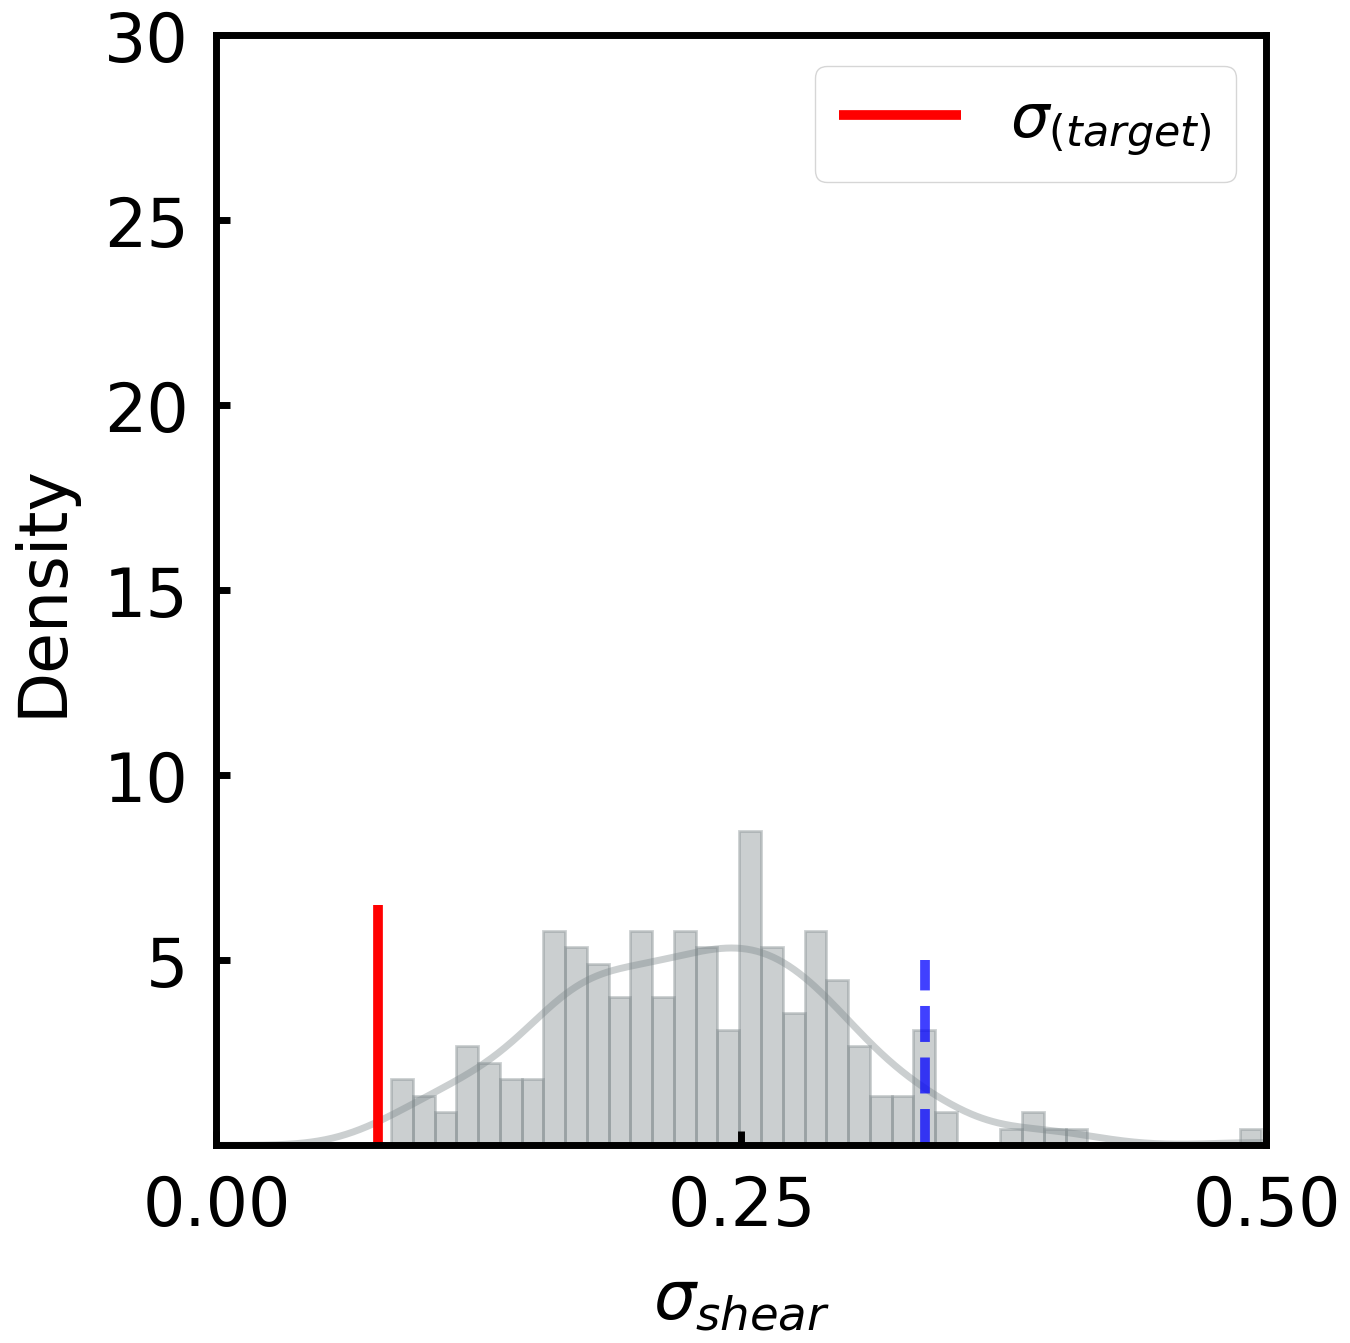

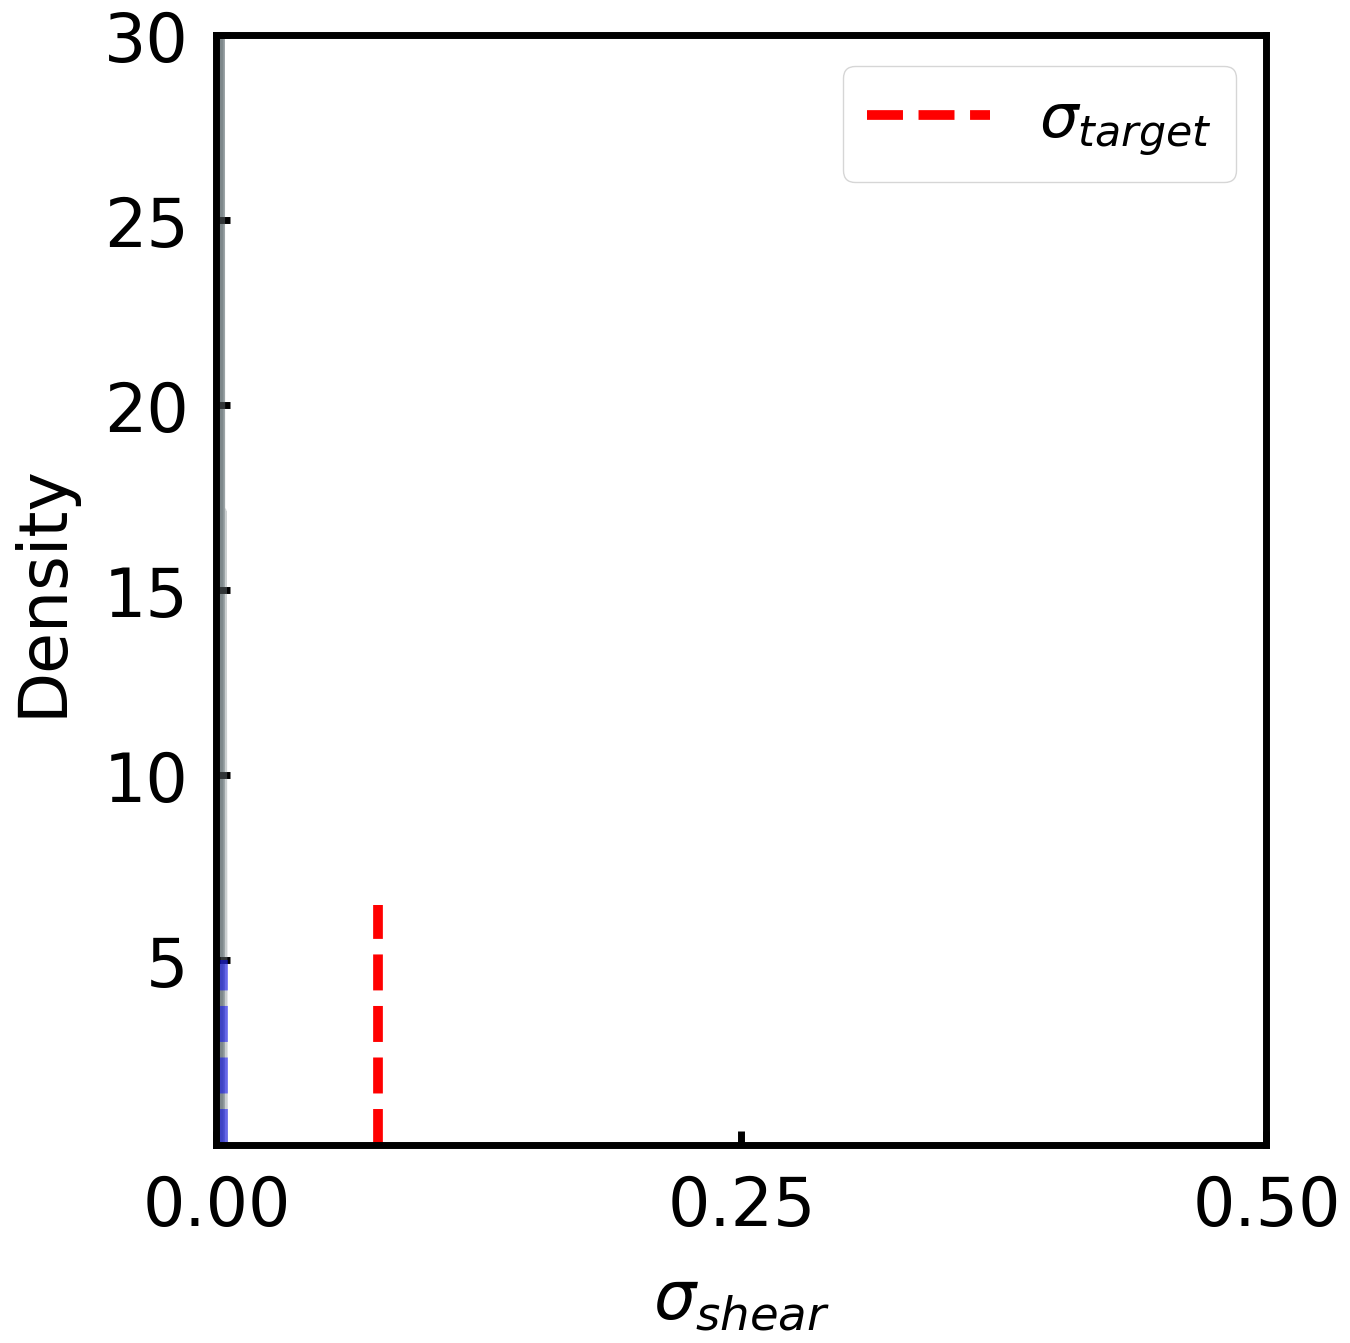

In [14]:
from toolbox import manuscriptPlots
from toolbox.periodic import PeriodicTissue
from toolbox.training import Training
from toolbox.stress import calculate_max_shear_stress
import numpy as np
import pandas as pd
import os

dir = "test_decrease_fail/"
os.makedirs(dir + "animation_assets/", exist_ok=True)

input_file = "init_config.txt".format(iter)
sample = PeriodicTissue.from_config(dir,input_file)
stresses = [calculate_max_shear_stress(sample,cellID) for cellID in sample.cells_]
df = pd.read_csv("{}initial_stress.csv".format(dir))
colors = ["cyan","blue","purple","green"]
colors = ["blue"]

df_target= pd.read_csv("{}0000.stresses.csv".format(dir))
target_stress = df_target["Target"].to_numpy()[0]
plotter = manuscriptPlots.plot()
plotter.set_ylim(0,30)
plotter.set_xlim(0,0.5)
plotter.set_xlabel(r"$\sigma_{shear}$")
plotter.set_xticks([0.25*i for i in range(10)])
plotter.set_yticks([5*i for i in range(1,10)])
# plotter.set_yScaled()
plotter.initialize_figure()
# plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
# errors = np.loadtxt(dir+ "errors.txt")
# epochs = [i+1 for i in range(len(errors))]
# plotter.plot_xy(epochs,errors,label = "Error", color= "red",alpha = 0.8)
# # plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)
plotter.histogram_from_array(stresses,bins = 40,alpha = 0.4)
for i,stress in enumerate(df["Current"].to_numpy()):
    plotter.ax.vlines(stress, ymin = 0, ymax = 5,linestyles= "--", color = colors[i],alpha = 0.75)
plotter.ax.vlines(target_stress, ymin = 0, ymax = 6.5,linestyles= "-", color = "red",alpha = 1,label = r"$\sigma_{(target)}$")
plotter.ax.legend()
plotter.save_fig(dir+"animation_assets/"+"0000.stress.jpg")

# for iter in [10*i-1 for i in range(1,23)]:
for iter in range(229,230):

    input_file = "{:04d}.bulk.txt".format(iter)
    sample = PeriodicTissue.from_config(dir,input_file)
    training_instance = Training.periodic_tissue(sample)
    training_instance.load_cell_parameters("{:04d}.cellParameters.input".format(iter))
    stresses = [calculate_max_shear_stress(training_instance._config,cellID) for cellID in training_instance._config.cells_]
    df = pd.read_csv("{}{:04d}.stresses.csv".format(dir,iter))

    plotter = manuscriptPlots.plot()
    plotter.set_ylim(0,30)
    plotter.set_xlim(0,0.5)
    # plotter.set_title(" p = {:.2f}".format(p))
    plotter.set_xlabel(r"$\sigma_{shear}$")
    # plotter.set_ylabel(r"$<\frac{|\sigma_{target}-\sigma|}{\sigma}>$")
    # # plotter.set_ylabel(r"$<\sum_{cells}{|s_{0,cell}^{(A)}-s_{0,cell}^{(B)}|}>$")

    plotter.set_xticks([0.25*i for i in range(10)])
    plotter.set_yticks([5*i for i in range(1,10)])
    # plotter.set_yScaled()
    plotter.initialize_figure()
    # plotter.ax.set_xscale("log")
    # plotter.ax.set_yscale("log")
    # errors = np.loadtxt(dir+ "errors.txt")
    # epochs = [i+1 for i in range(len(errors))]
    # plotter.plot_xy(epochs,errors,label = "Error", color= "red",alpha = 0.8)
    # # plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)
    plotter.histogram_from_array(stresses,bins = 40,alpha = 0.4)
    for i,stress in enumerate(df["Current"].to_numpy()):
        plotter.ax.vlines(stress, ymin = 0, ymax = 5,linestyles= "--", color = colors[i],alpha = 0.5)
    plotter.ax.vlines(target_stress, ymin = 0, ymax = 6.5,linestyles= "--", color = "red",alpha = 1,label = r"$\sigma_{target}$")
    plotter.ax.legend()
    plotter.save_fig(dir+"animation_assets/"+"{:04d}.stress.jpg".format(iter+1))


In [15]:
import os
from PIL import Image, ImageDraw

# Path to your folder
folder = "test_decrease_fail/animation_assets/"

# Get sorted list of jpgs (assuming format 0000.stress.jpg ... 1000.stress.jpg)
files = sorted([f for f in os.listdir(folder) if f.endswith(".jpg")])

frames = []
n_files = len(files)

for i, filename in enumerate(files):
    # Load image
    img_path = os.path.join(folder, filename)
    img = Image.open(img_path).convert("RGB")

    # Draw progress bar
    draw = ImageDraw.Draw(img)
    bar_height = 100
    bar_margin = 50
    progress = (i + 1) / n_files
    bar_width = int(progress * (img.width - 2 * bar_margin))

    # # Background bar (gray)
    # draw.rectangle(
    #     [bar_margin, img.height - bar_height - bar_margin,
    #      img.width - bar_margin, img.height - bar_margin],
    #     fill=(200, 200, 200)
    # )

    # # Progress bar (blue/green/etc.)
    # draw.rectangle(
    #     [bar_margin, img.height - bar_height - bar_margin,
    #      bar_margin + bar_width, img.height - bar_margin],
    #     fill=(50, 150, 255)
    # )

    # frames.append(img)
    
    # Background bar (gray)
    draw.rectangle(
        [bar_margin, bar_margin,
        img.width - bar_margin, bar_margin + bar_height],
        fill=(200, 200, 200)
    )

    # Progress bar (blue)
    draw.rectangle(
        [bar_margin, bar_margin,
        bar_margin + bar_width, bar_margin + bar_height],
        fill=(50, 150, 255)
    )
    frames.append(img)


# Save gif
frames[0].save("test_decrease_fail/graphs/stress_hist.gif",
               save_all=True,
               append_images=frames[1:],
               duration=500,   # ms per frame
               loop=0)         # loop forever


In [13]:
frames[0].save("test_decrease_fail/graphs/stress_hist.gif",
               save_all=True,
               append_images=frames[1:],
               duration=1000,   # ms per frame
               loop=0)       

In [ ]:
import numpy as np

dir = "tests/6_5.0/"
errors = np.loadtxt("{}errors.txt".format(dir))
grad_error = np.gradient(errors)
change_iters = []
for i,g in enumerate(grad_error):
    if i == 0:
        continue
    # if np.sign(g) == -1:
    #     continue
    # if abs(grad_error[i-1]-grad_error[i+1])<1e-6:
    #     continue
    # print(g)
    if abs(g)<1e-2:
        continue
    change_iters.append(i)
change_iters.append(len(errors)-2)
change_iters = np.unique(change_iters)
print(change_iters, len(change_iters))


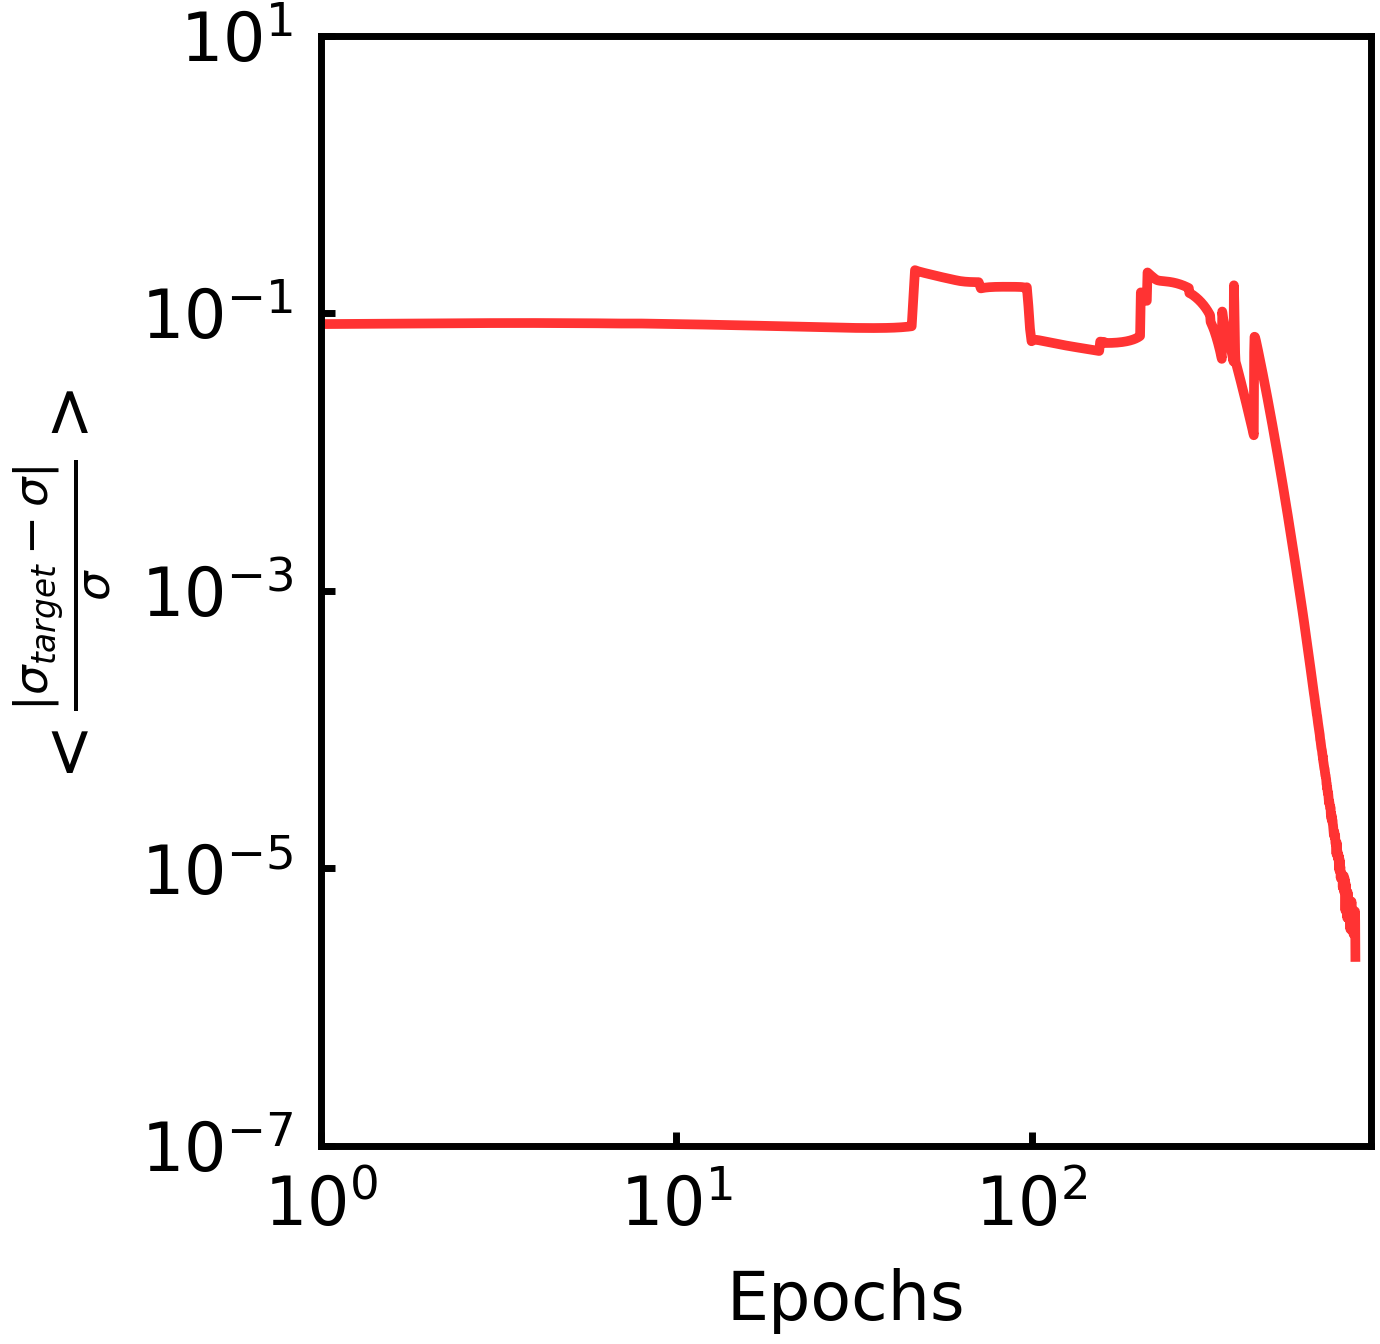

In [2]:
from toolbox import manuscriptPlots
from scripts.data_processing import write_average_error
from scripts.data_processing import download
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

dir = "test_2_cells/"
os.makedirs(dir+"graphs/", exist_ok=True)
write_average_error(dir)

input_file = "{}errors.txt".format(dir)
plotter = manuscriptPlots.plot()
# plotter.width=0.6
# plotter.height=0.7

plotter.set_ylim(1e-7,10)
plotter.set_xlim(1,900)
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$<\frac{|\sigma_{target}-\sigma|}{\sigma}>$")
# plotter.set_ylabel(r"$<\sum_{cells}{|s_{0,cell}^{(A)}-s_{0,cell}^{(B)}|}>$")

plotter.set_xticks([500*i for i in range(100)])
plotter.set_yticks([0.05*i for i in range(1,10)])
plotter.set_yScaled()

plotter.initialize_figure()
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")
errors = np.loadtxt(input_file)
epochs = [i for i in range(len(errors))]
plotter.plot_xy(epochs,errors, label= "Error", color= "red",alpha = 0.8)
plotter.save_fig("{}graphs/error.jpg".format(dir))
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)

# overlaps = np.loadtxt(dir+ "overlaps.txt")
# plotter.ax2 = plotter.ax.twinx()
# plotter.ax2.set_position([plotter.leftMargin, plotter.bottomMargin, plotter.width, plotter.height]) 
# # plotter.ax2.set_xlim(0.5,1)
# plotter.ax2.plot(epochs, overlaps, color="blue",alpha =0.6, label = "Overlap")
# plotter.ax2.set_ylabel( r"$Q$")
# plotter.ax.legend(loc = "upper right")
# plotter.ax2.legend(loc = "upper right")

# plotter.save_fig(dir+"graphs/error.jpg")

# df = pd.read_csv("../tvm-fire/sp_5_cell_increase/costs.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}>\sigma_{initial}$", color= "blue",alpha = 0.8)

# df = pd.read_csv("../tvm-fire/mp_2_cells/patternA_costs.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = "Pattern A", color= "red",alpha = 0.6)

# df = pd.read_csv("../tvm-fire/mp_2_cells/patternB_costs.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = "Pattern B", color= "blue",alpha = 0.6)

# df = pd.read_csv("../tvm-fire/mp_2_cells/distances.csv")
# costs = df["mean"].to_numpy()
# err = df["sem"].to_numpy()
# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = "_Pattern A", color= "black",alpha = 0.6)

# plotter.save_fig("/Users/shabeebameen/Projects/tvm-fire/mp_2_cells_distances.jpg")


In [ ]:
from toolbox import manuscriptPlots
from scripts.data_processing import write_average_error
from scripts.data_processing import download
import numpy as np
import pandas as pd
import os

dir = "tests/6_5.0/"
input_file = "{}overlaps.csv".format(dir)
df = pd.read_csv(input_file)
plotter = manuscriptPlots.plot()
plotter.set_ylim(1e-4,1.2)
plotter.set_xlim(1,1100)
# plotter.set_title(" p = {:.2f}".format(p))
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$<\frac{|\sigma_{target}-\sigma|}{\sigma}>$")
# plotter.set_ylabel(r"$<\sum_{cells}{|s_{0,cell}^{(A)}-s_{0,cell}^{(B)}|}>$")

plotter.set_xticks([200*i for i in range(2000)])
plotter.set_yticks([0.2*i for i in range(1,10)])
plotter.set_yScaled()

plotter.initialize_figure()
# plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
# plotter.set_yLog()
errors = np.loadtxt(dir+ "errors.txt")
epochs = [i+1 for i in range(len(errors))]
plotter.plot_xy(epochs,errors,label = "Error", color= "red",alpha = 0.8)
overlaps = np.loadtxt(dir+ "overlaps.txt")
plotter.plot_xy(epochs,overlaps,label = "Overlap", color= "blue",alpha = 0.2)
# grads = np.gradient(overlaps)
# for i,g in enumerate(grads):
#     # print(g)
#     if i ==0:
#         continue
#     if i==len(overlaps):
#         continue
#     if g == 0 and grads [i-1]== 0:
#         continue
#     if abs(g-grads [i-1]) <5e-3:
#         continue
#     plotter.ax.vlines(epochs[i], ymin = 0, ymax = 2,linestyles= "--", colors = 'purple',alpha = 0.3)

# plotter.plot_xy_errorbar([i for i in range(len(costs))],costs, err, label = r"$\sigma_{trained}<\sigma_{initial}$", color= "red",alpha = 0.8)
plotter.save_fig("{}overlaps.jpg".format(dir))

